In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irfanahammad/employee-attrition-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'employee-attrition-prediction' dataset.
Path to dataset files: /kaggle/input/employee-attrition-prediction


In [ ]:
import os
print(os.listdir(path))

['employee_attrition_noisy.csv']


In [ ]:
df=pd.read_csv(path+"/employee_attrition_noisy.csv")
df.head()

,EmployeeID,Age,Gender,MaritalStatus,EducationLevel,JobRole,Department,YearsAtCompany,YearsInCurrentRole,TotalWorkingYears,...,BusinessTravel,DistanceFromHome,OverTime,NumCompaniesWorked,StockOptionLevel,PercentSalaryHike,RemoteWork,ManagerRating,PromotionLast5Years,Attrition
0,522210,39,Male,Married,High School,Senior Analyst,Finance,6,0,18,...,Travel_Frequently,3,No,0,0,22,No,5,No,No
1,863706,35,Female,Divorced,Associate,Customer Success Manager,Customer Support,8,5,10,...,Travel_Frequently,17,Yes,0,0,12,Yes,2,Yes,No
2,869105,43,Female,Married,Master,Brand Analyst,Marketing,10,8,19,...,Travel_Frequently,38,No,1,0,7,No,4,No,No
3,256574,34,Female,Divorced,High School,Brand Analyst,Marketing,5,3,11,...,Travel_Frequently,8,No,2,0,15,No,4,No,No
4,260565,49,Male,Single,PhD,Support Lead,Customer Support,2,0,19,...,Travel_Rarely,8,No,1,1,13,No,3,No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15800 entries, 0 to 15799
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               15800 non-null  int64 
 1   Age                      15800 non-null  int64 
 2   Gender                   15800 non-null  object
 3   MaritalStatus            15800 non-null  object
 4   EducationLevel           15800 non-null  object
 5   JobRole                  15800 non-null  object
 6   Department               15800 non-null  object
 7   YearsAtCompany           15800 non-null  int64 
 8   YearsInCurrentRole       15800 non-null  int64 
 9   TotalWorkingYears        15800 non-null  int64 
 10  MonthlyIncome            15800 non-null  int64 
 11  JobSatisfaction          15800 non-null  int64 
 12  WorkLifeBalance          15800 non-null  int64 
 13  EnvironmentSatisfaction  15800 non-null  int64 
 14  PerformanceRating        15800 non-nul

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,12929
Yes,2871


##EDA

In [ ]:
df.isnull().sum()

,0
EmployeeID,0
Age,0
Gender,0
MaritalStatus,0
EducationLevel,0
JobRole,0
Department,0
YearsAtCompany,0
YearsInCurrentRole,0
TotalWorkingYears,0


In [ ]:
df["Attrition"]

,Attrition
0,No
1,No
2,No
3,No
4,No
...,...
15795,No
15796,No
15797,Yes
15798,No


##Visulise

<Axes: >

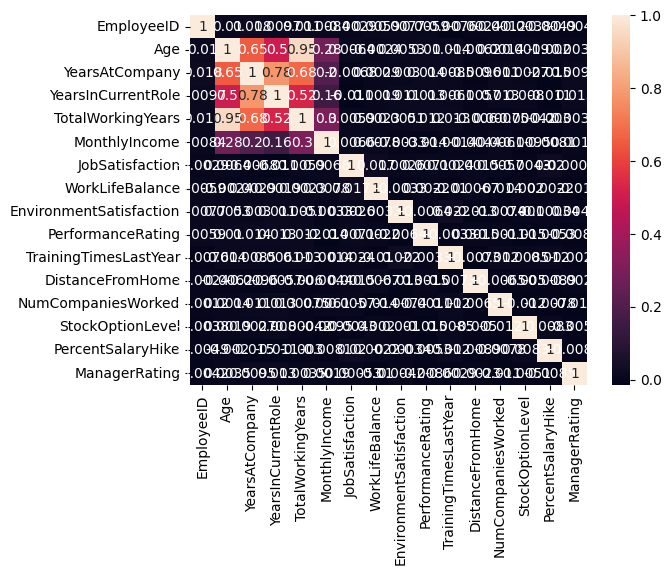

In [ ]:

sns.heatmap(df.corr(numeric_only=True),annot=True)


In [ ]:

cor=df.corr(numeric_only=True)["MonthlyIncome"]
print(cor.sort_values(ascending=False))

MonthlyIncome              1.000000
TotalWorkingYears          0.301089
Age                        0.280951
YearsAtCompany             0.200847
YearsInCurrentRole         0.155426
EmployeeID                 0.008375
WorkLifeBalance            0.007751
JobSatisfaction            0.006599
NumCompaniesWorked         0.006065
ManagerRating              0.001947
TrainingTimesLastYear     -0.001367
EnvironmentSatisfaction   -0.003303
DistanceFromHome          -0.004433
PercentSalaryHike         -0.008116
StockOptionLevel          -0.009529
PerformanceRating         -0.013825
Name: MonthlyIncome, dtype: float64


##Encode

In [ ]:
encode=pd.get_dummies(df,drop_first=True)
encode.head()

,EmployeeID,Age,YearsAtCompany,YearsInCurrentRole,TotalWorkingYears,MonthlyIncome,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,PerformanceRating,...,Department_IT,Department_Marketing,Department_Operations,Department_Sales,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,OverTime_Yes,RemoteWork_Yes,PromotionLast5Years_Yes,Attrition_Yes
0,522210,39,6,0,18,5571,4,4,3,4,...,False,False,False,False,True,False,False,False,False,False
1,863706,35,8,5,10,4596,3,4,4,5,...,False,False,False,False,True,False,True,True,True,False
2,869105,43,10,8,19,8498,2,2,3,5,...,False,True,False,False,True,False,False,False,False,False
3,256574,34,5,3,11,3280,3,4,4,5,...,False,True,False,False,True,False,False,False,False,False
4,260565,49,2,0,19,13580,3,3,2,3,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15800 entries, 0 to 15799
Data columns (total 63 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   EmployeeID                        15800 non-null  int64
 1   Age                               15800 non-null  int64
 2   YearsAtCompany                    15800 non-null  int64
 3   YearsInCurrentRole                15800 non-null  int64
 4   TotalWorkingYears                 15800 non-null  int64
 5   MonthlyIncome                     15800 non-null  int64
 6   JobSatisfaction                   15800 non-null  int64
 7   WorkLifeBalance                   15800 non-null  int64
 8   EnvironmentSatisfaction           15800 non-null  int64
 9   PerformanceRating                 15800 non-null  int64
 10  TrainingTimesLastYear             15800 non-null  int64
 11  DistanceFromHome                  15800 non-null  int64
 12  NumCompaniesWorked              

##X and Y

In [ ]:
X=encode.drop("Attrition_Yes",axis=1)
y=encode["Attrition_Yes"]


##Train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

##Standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_train=pd.DataFrame(Scaler.fit_transform(X_train),columns=X_train.columns)
X_test=pd.DataFrame(Scaler.transform(X_test),columns=X_test.columns)

##Train SVM

In [ ]:
from sklearn.svm import SVC
model=SVC(kernel="linear")
model.fit(X_train,y_train)

SVC(kernel='linear')

##Accuracy

In [ ]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.825632911392405
[[2609    0]
 [ 551    0]]
              precision    recall  f1-score   support

       False       0.83      1.00      0.90      2609
        True       0.00      0.00      0.00       551

    accuracy                           0.83      3160
   macro avg       0.41      0.50      0.45      3160
weighted avg       0.68      0.83      0.75      3160



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model = SVC(
    kernel='rbf',
    class_weight='balanced'
)
model.fit(X_train, y_train)

SVC(class_weight='balanced')

In [ ]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7066455696202532
[[1885  724]
 [ 203  348]]
              precision    recall  f1-score   support

       False       0.90      0.72      0.80      2609
        True       0.32      0.63      0.43       551

    accuracy                           0.71      3160
   macro avg       0.61      0.68      0.62      3160
weighted avg       0.80      0.71      0.74      3160

